# 07 · Modélisation Prédictive — Machine Learning & Séries Temporelles
## CEET Smart Grid – Energy Blackout Prediction
**Objectif :** Entraîner, évaluer et comparer plusieurs modèles pour :
- Prédire les blackouts (classification binaire)
- Prédire les surcharges (classification binaire)
- Prévoir la demande énergétique (régression)

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
import plotly.express as px
import plotly.graph_objects as go
from modeling import (run_blackout_modeling, run_overload_modeling,
                      run_demand_forecasting, get_classifiers, prepare_data,
                      get_feature_importance)
from feature_engineering import BLACKOUT_FEATURES, OVERLOAD_FEATURES, DEMAND_FEATURES, get_feature_matrix
from time_series import prepare_timeseries, test_stationarity, fit_sarima, SimpleLSTMNumpy
from utils import DATA_PROC, FIGURES

df = pd.read_csv(DATA_PROC / 'ceet_processed.csv', parse_dates=['datetime'])
print(f"Dataset : {df.shape}")
print(f"Blackout rate : {df['blackout'].mean()*100:.2f}%")

Dataset : (50000, 75)
Blackout rate : 3.95%


### 7.1 Prédiction des Blackouts — Comparaison de Modèles

In [2]:
print("Lancement du pipeline de modélisation blackout...")
results_blackout = run_blackout_modeling(df)
print("\n=== CLASSEMENT DES MODÈLES (Blackout) ===")
cols = ['model','f1_score','roc_auc','recall','precision','accuracy']
avail_cols = [c for c in cols if c in results_blackout['results'].columns]
print(results_blackout['results'][avail_cols].to_string(index=False))

2026-06-10 19:28:34 | INFO     | modeling | ============================================================
2026-06-10 19:28:34 | INFO     | modeling | MODÉLISATION : PRÉDICTION BLACKOUT
2026-06-10 19:28:34 | INFO     | modeling | ============================================================
2026-06-10 19:28:34 | INFO     | modeling | Train : (40000, 44), Test : (10000, 44)
2026-06-10 19:28:34 | INFO     | modeling | Distribution target (test) :
blackout
0    0.96
1    0.04
Name: proportion, dtype: float64
2026-06-10 19:28:34 | INFO     | modeling | Entraînement : logistic_regression...


Lancement du pipeline de modélisation blackout...


2026-06-10 19:28:35 | INFO     | modeling |   F1=0.6272 | ROC-AUC=0.9876 | Recall=0.9924
2026-06-10 19:28:35 | INFO     | modeling | Entraînement : random_forest...
2026-06-10 19:28:41 | INFO     | modeling |   F1=0.8107 | ROC-AUC=0.9911 | Recall=0.9975
2026-06-10 19:28:41 | INFO     | modeling | Entraînement : gradient_boosting...
2026-06-10 19:30:36 | INFO     | modeling |   F1=0.8017 | ROC-AUC=0.9912 | Recall=0.9671
2026-06-10 19:30:36 | INFO     | modeling | Entraînement : xgboost...
2026-06-10 19:30:40 | INFO     | modeling |   F1=0.8050 | ROC-AUC=0.9914 | Recall=0.9873
2026-06-10 19:30:40 | INFO     | modeling | Entraînement : lightgbm...
2026-06-10 19:30:41 | INFO     | modeling |   F1=0.8066 | ROC-AUC=0.9907 | Recall=0.9975
2026-06-10 19:30:41 | INFO     | modeling | Entraînement : catboost...
2026-06-10 19:30:46 | INFO     | modeling |   F1=0.7887 | ROC-AUC=0.9912 | Recall=0.9873
2026-06-10 19:30:53 | INFO     | modeling | Ensemble VotingClassifier entraîné
2026-06-10 19:30:53


=== CLASSEMENT DES MODÈLES (Blackout) ===
              model  f1_score  roc_auc  recall  precision  accuracy
      random_forest    0.8107   0.9911  0.9975     0.6828    0.9816
           lightgbm    0.8066   0.9907  0.9975     0.6770    0.9811
    ensemble_voting    0.8058   0.9908  0.9823     0.6831    0.9813
            xgboost    0.8050   0.9914  0.9873     0.6794    0.9811
  gradient_boosting    0.8017   0.9912  0.9671     0.6846    0.9811
           catboost    0.7887   0.9912  0.9873     0.6566    0.9791
logistic_regression    0.6272   0.9876  0.9924     0.4585    0.9534


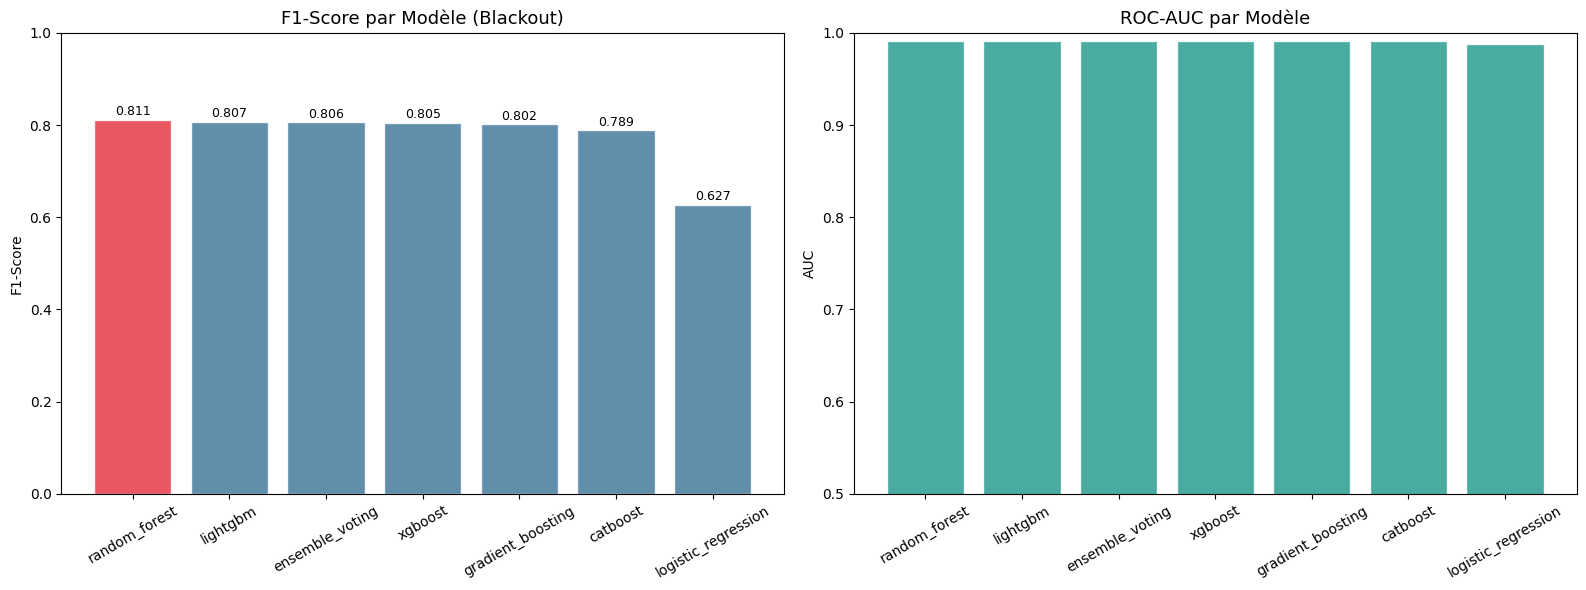

In [3]:
# Visualisation de la comparaison
res_df = results_blackout['results']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(res_df['model'], res_df['f1_score'],
                   color=['#E63946' if i == 0 else '#457B9D' for i in range(len(res_df))],
                   edgecolor='white', alpha=0.85)
axes[0].set_title('F1-Score par Modèle (Blackout)', fontsize=13)
axes[0].set_ylabel('F1-Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars, res_df['f1_score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9)

if 'roc_auc' in res_df.columns:
    axes[1].bar(res_df['model'], res_df['roc_auc'],
               color='#2A9D8F', edgecolor='white', alpha=0.85)
    axes[1].set_title('ROC-AUC par Modèle', fontsize=13)
    axes[1].set_ylabel('AUC')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig(FIGURES / 'model_comparison_blackout.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.2 Feature Importance du Meilleur Modèle

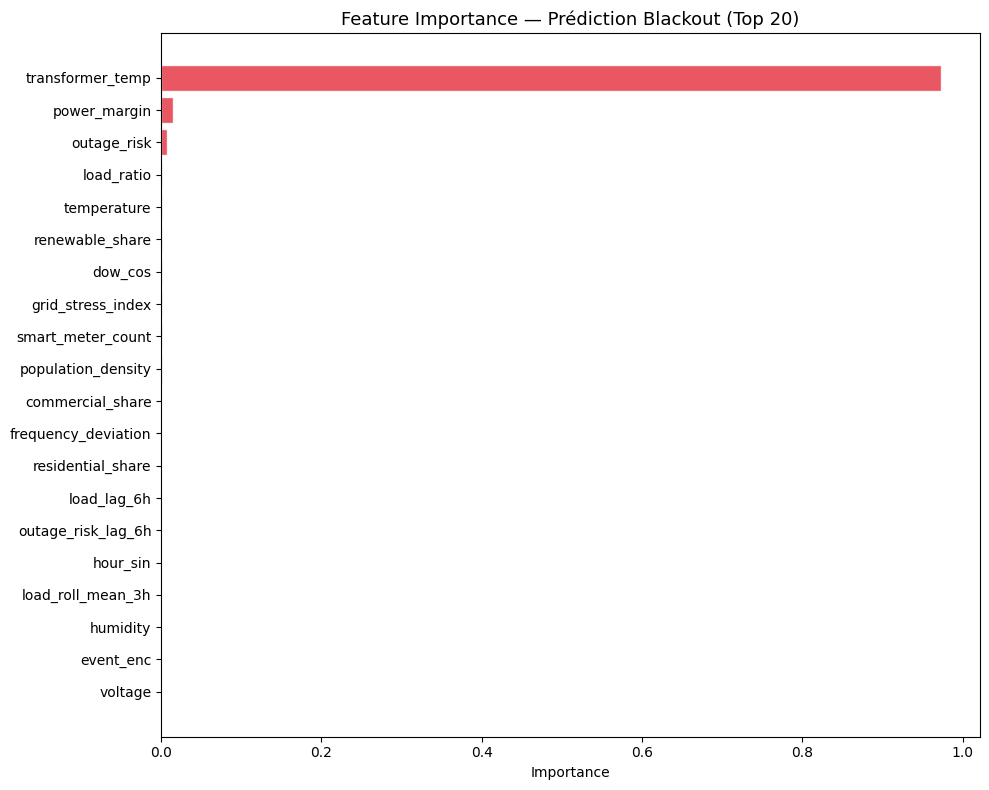

In [4]:
best = results_blackout['best_model']
avail_feats = [f for f in BLACKOUT_FEATURES if f in df.columns]

# Tenter d'extraire l'estimateur sous-jacent
model_to_inspect = best
if hasattr(best, 'estimators_'):
    # VotingClassifier → prendre le premier estimateur
    model_to_inspect = best.estimators_[0]

fi_df = get_feature_importance(model_to_inspect, avail_feats, top_n=20)
if not fi_df.empty:
    fig, ax = plt.subplots(figsize=(10, 8))
    fi_sorted = fi_df.sort_values('importance')
    colors = ['#E63946' if i >= len(fi_sorted)-3 else '#457B9D' for i in range(len(fi_sorted))]
    ax.barh(fi_sorted['feature'], fi_sorted['importance'], color=colors, edgecolor='white', alpha=0.85)
    ax.set_title('Feature Importance — Prédiction Blackout (Top 20)', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(FIGURES / 'feature_importance_blackout.png', dpi=120, bbox_inches='tight')
    plt.show()

### 7.3 Prédiction des Surcharges

In [5]:
results_overload = run_overload_modeling(df)
print("\n=== CLASSEMENT DES MODÈLES (Surcharge) ===")
avail_cols_ol = [c for c in ['model','f1_score','recall','precision'] if c in results_overload['results'].columns]
print(results_overload['results'][avail_cols_ol].to_string(index=False))

2026-06-10 19:51:05 | INFO     | modeling | ============================================================
2026-06-10 19:51:05 | INFO     | modeling | MODÉLISATION : PRÉDICTION SURCHARGE
2026-06-10 19:51:05 | INFO     | modeling | ============================================================
2026-06-10 19:51:05 | INFO     | modeling | Train : (40000, 30), Test : (10000, 30)
2026-06-10 19:51:05 | INFO     | modeling | Distribution target (test) :
overload
1    0.825
0    0.175
Name: proportion, dtype: float64
2026-06-10 19:51:05 | INFO     | modeling | Entraînement : logistic_regression...
2026-06-10 19:51:06 | INFO     | modeling |   F1=0.9921 | ROC-AUC=1.0 | Recall=0.9842
2026-06-10 19:51:06 | INFO     | modeling | Entraînement : random_forest...
2026-06-10 19:51:09 | INFO     | modeling |   F1=1.0000 | ROC-AUC=1.0 | Recall=1.0000
2026-06-10 19:51:09 | INFO     | modeling | Entraînement : gradient_boosting...
2026-06-10 19:51:48 | INFO     | modeling |   F1=1.0000 | ROC-AUC=1.0 | Recall=


=== CLASSEMENT DES MODÈLES (Surcharge) ===
              model  f1_score  recall  precision
      random_forest    1.0000  1.0000        1.0
  gradient_boosting    1.0000  1.0000        1.0
           lightgbm    1.0000  1.0000        1.0
           catboost    0.9996  0.9992        1.0
            xgboost    0.9995  0.9989        1.0
logistic_regression    0.9921  0.9842        1.0


### 7.4 Prévision de la Demande Énergétique

In [6]:
results_demand = run_demand_forecasting(df)
print("\n=== MODÈLES DE FORECASTING (Demande) ===")
print(results_demand['results'][['model','rmse','mae','r2']].to_string(index=False))

2026-06-10 20:12:18 | INFO     | modeling | ============================================================
2026-06-10 20:12:18 | INFO     | modeling | MODÉLISATION : FORECASTING DE LA DEMANDE
2026-06-10 20:12:18 | INFO     | modeling | ============================================================
2026-06-10 20:12:18 | INFO     | modeling | Entraînement : ridge...
2026-06-10 20:12:19 | INFO     | modeling |   RMSE=33.4893 | MAE=26.7083 | R²=0.5572
2026-06-10 20:12:19 | INFO     | modeling | Entraînement : random_forest_reg...
2026-06-10 20:12:46 | INFO     | modeling |   RMSE=32.8824 | MAE=26.1543 | R²=0.5731
2026-06-10 20:12:46 | INFO     | modeling | Entraînement : xgboost_reg...
2026-06-10 20:12:47 | INFO     | modeling |   RMSE=32.6894 | MAE=25.9581 | R²=0.5781
2026-06-10 20:12:47 | INFO     | modeling | Entraînement : lightgbm_reg...
2026-06-10 20:12:48 | INFO     | modeling |   RMSE=32.6025 | MAE=25.9084 | R²=0.5804



=== MODÈLES DE FORECASTING (Demande) ===
            model    rmse     mae     r2
     lightgbm_reg 32.6025 25.9084 0.5804
      xgboost_reg 32.6894 25.9581 0.5781
random_forest_reg 32.8824 26.1543 0.5731
            ridge 33.4893 26.7083 0.5572


### 7.5 Analyse des Séries Temporelles (SARIMA + LSTM)

In [7]:
ts = prepare_timeseries(df, target='total_load_mw', freq='h')
print(f"Série temporelle : {len(ts)} points")

# Test de stationnarité
stat_result = test_stationarity(ts, 'Charge Totale (MW)')
print("\n=== TEST ADF ===")
for k, v in stat_result.items():
    print(f"  {k:20s}: {v}")

2026-06-10 20:15:14 | INFO     | time_series | Série temporelle : 50000 points | 2020-01-01 00:00:00 → 2025-09-14 07:00:00


Série temporelle : 50000 points


2026-06-10 20:15:27 | INFO     | time_series | ADF Test – Charge Totale (MW): STATIONNAIRE (p=0.0000)



=== TEST ADF ===
  ADF Statistic       : -28.8095
  p-value             : 0.0
  Lags                : 57
  Observations        : 49942
  Critical 1%         : -3.4305
  Critical 5%         : -2.8616
  Is stationary       : True


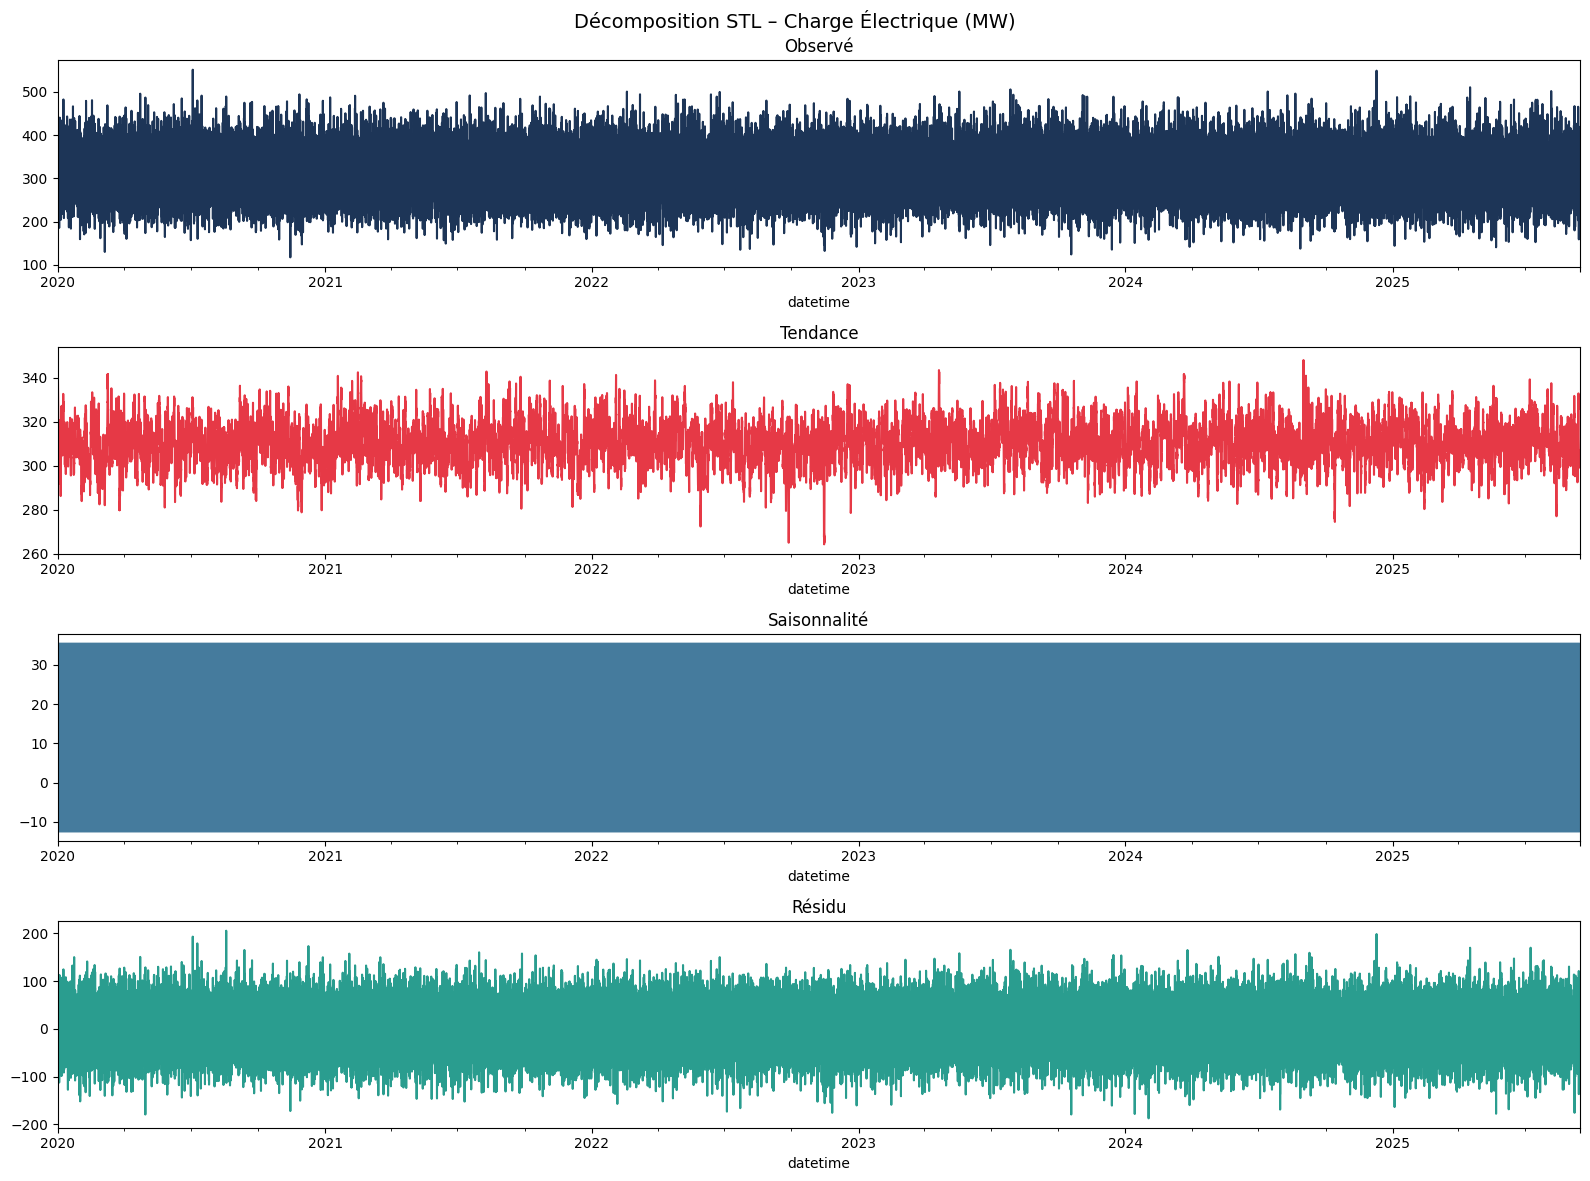

In [8]:
# Décomposition saisonnière
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(ts, model='additive', period=24, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
decomp.observed.plot(ax=axes[0], title='Observé', color='#1D3557')
decomp.trend.plot(ax=axes[1], title='Tendance', color='#E63946')
decomp.seasonal.plot(ax=axes[2], title='Saisonnalité', color='#457B9D')
decomp.resid.plot(ax=axes[3], title='Résidu', color='#2A9D8F')
plt.suptitle('Décomposition STL – Charge Électrique (MW)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES / 'ts_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

2026-06-10 20:17:19 | INFO     | time_series | SARIMA(1, 1, 1) × (1, 1, 1, 24)...
2026-06-10 20:17:23 | INFO     | time_series |   AIC=1386.48 | BIC=1400.62
2026-06-10 20:17:23 | INFO     | time_series |   MAE=31.07 | RMSE=37.60 | MAPE=10.79%


=== MÉTRIQUES SARIMA ===
  MAE       : 31.0749
  RMSE      : 37.5950
  MAPE      : 10.7922


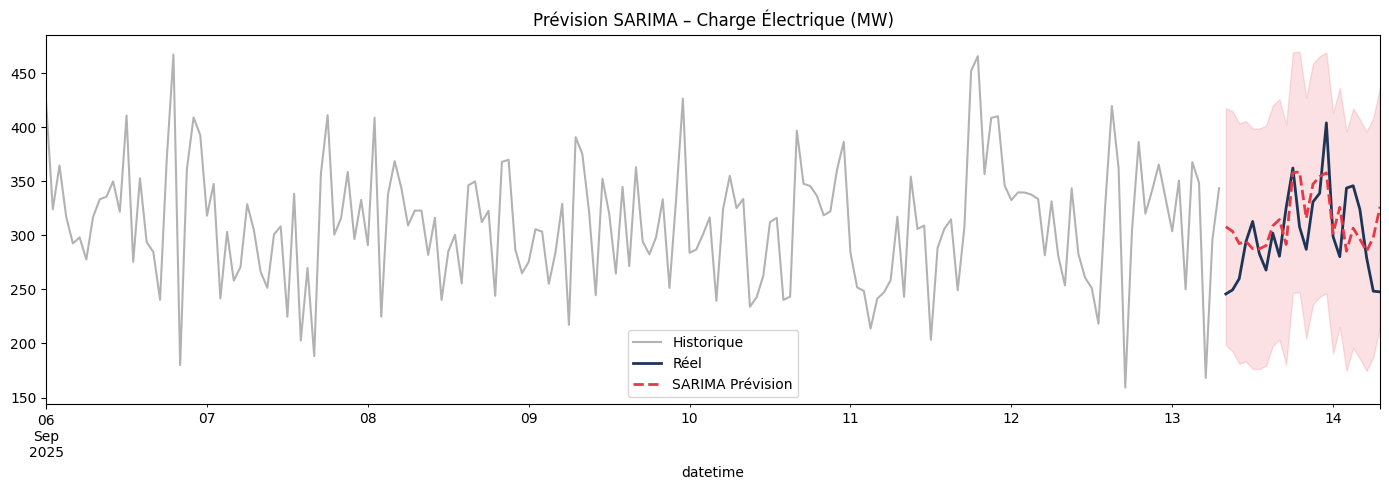

In [9]:
# SARIMA sur un sous-ensemble (100 dernières heures)
ts_small = ts[-200:]
try:
    sarima_result = fit_sarima(ts_small, order=(1,1,1), seasonal_order=(1,1,1,24), n_forecast=24)
    print("=== MÉTRIQUES SARIMA ===")
    for k, v in sarima_result['metrics'].items():
        print(f"  {k.upper():10s}: {v:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    sarima_result['train'].plot(ax=ax, label='Historique', color='gray', alpha=0.6)
    sarima_result['test'].plot(ax=ax, label='Réel', color='#1D3557', linewidth=2)
    sarima_result['forecast'].plot(ax=ax, label='SARIMA Prévision', color='#E63946',
                                   linewidth=2, linestyle='--')
    ax.fill_between(sarima_result['conf_int'].index,
                    sarima_result['conf_int'].iloc[:,0],
                    sarima_result['conf_int'].iloc[:,1],
                    alpha=0.15, color='#E63946')
    ax.set_title('Prévision SARIMA – Charge Électrique (MW)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / 'sarima_forecast.png', dpi=120, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"SARIMA non exécuté : {e}")

2026-06-10 20:17:35 | INFO     | time_series | SimpleLSTM entraîné : window=24, horizon=6



SimpleLSTM (fenêtre glissante + Ridge) :
  MAE  : 38.80 MW
  RMSE : 51.04 MW
  MAPE : 14.58%


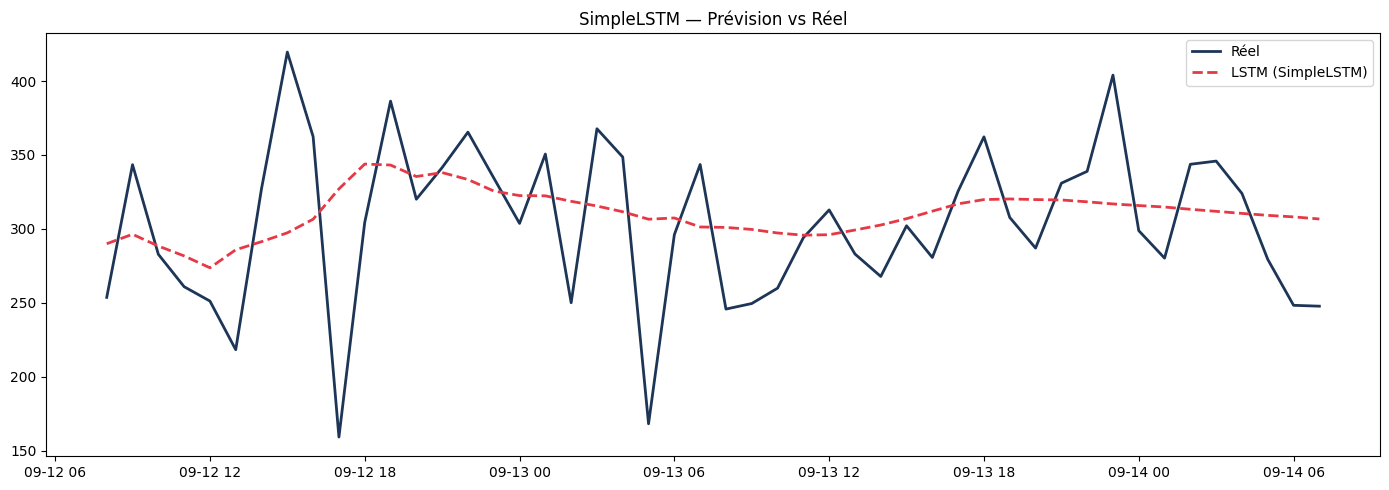

In [10]:
# SimpleLSTM
print("\nSimpleLSTM (fenêtre glissante + Ridge) :")
train_ts, test_ts = ts[:-48], ts[-48:]
lstm = SimpleLSTMNumpy(window=24, horizon=6)
lstm.fit(train_ts)
metrics_lstm = lstm.evaluate(test_ts, train_ts)
print(f"  MAE  : {metrics_lstm['mae']:.2f} MW")
print(f"  RMSE : {metrics_lstm['rmse']:.2f} MW")
print(f"  MAPE : {metrics_lstm['mape']:.2f}%")

forecast_lstm = lstm.predict(train_ts, n_steps=48)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_ts.index, test_ts.values, label='Réel', color='#1D3557', linewidth=2)
ax.plot(test_ts.index[:len(forecast_lstm)], forecast_lstm,
        label='LSTM (SimpleLSTM)', color='#E63946', linewidth=2, linestyle='--')
ax.set_title('SimpleLSTM — Prévision vs Réel')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'lstm_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.6 Détection d'Anomalies

In [13]:
from anomaly_detection import combine_anomaly_detectors

df_with_anomalies, ae_model = combine_anomaly_detectors(df)
n_anom = df_with_anomalies['is_anomaly'].sum()
print(f"\n Anomalies détectées : {n_anom} ({n_anom/len(df)*100:.2f}%)")
print("\nTop 10 anomalies critiques :")
top = df_with_anomalies[df_with_anomalies['is_anomaly']==1].sort_values('anomaly_risk_score', ascending=False)
print(top[['datetime','region','city','total_load_mw','outage_risk','anomaly_risk_score']].head(10).to_string(index=False))

2026-06-10 20:18:49 | INFO     | anomaly_detection | ============================================================
2026-06-10 20:18:49 | INFO     | anomaly_detection | DÉTECTION D'ANOMALIES MULTI-MÉTHODES
2026-06-10 20:18:49 | INFO     | anomaly_detection | ============================================================
2026-06-10 20:18:49 | INFO     | anomaly_detection | Isolation Forest...
2026-06-10 20:18:52 | INFO     | anomaly_detection |   2500 anomalies détectées (5% seuil)
2026-06-10 20:18:53 | INFO     | anomaly_detection | AutoEncoder (PCA-based)...
2026-06-10 20:18:53 | INFO     | anomaly_detection |   AutoEncoder PCA : variance expliquée = 91.71%
2026-06-10 20:18:53 | INFO     | anomaly_detection |   Seuil reconstruction (p95) = 0.2643
2026-06-10 20:18:53 | INFO     | anomaly_detection |   2500 anomalies détectées par AutoEncoder
2026-06-10 20:18:53 | INFO     | anomaly_detection | DBSCAN (eps=0.8, min_samples=15)...
2026-06-10 20:18:56 | INFO     | anomaly_detection |   1 clus


 Anomalies détectées : 2210 (4.42%)

Top 10 anomalies critiques :
           datetime   region    city  total_load_mw  outage_risk  anomaly_risk_score
2022-02-03 22:00:00 Plateaux  Sokode         385.02       100.00               76.69
2021-12-15 04:00:00 Centrale  Sokode         230.12        92.18               76.26
2022-11-13 15:00:00     Lome  Sokode         356.25       100.00               74.26
2020-11-06 23:00:00  Savanes    Kara         350.32       100.00               73.83
2021-12-13 02:00:00 Centrale    Lome         355.42       100.00               72.99
2020-07-03 19:00:00 Centrale Dapaong         551.42       100.00               72.77
2020-01-23 21:00:00     Lome    Kara         347.47       100.00               72.26
2023-07-01 14:00:00 Plateaux Kpalime         366.35       100.00               72.24
2024-12-09 21:00:00 Centrale  Tsevie         549.20       100.00               72.05
2023-04-10 21:00:00     Lome    Kara         397.00       100.00               71.0

### 7.7 Résumé Final

In [14]:
print("=" * 65)
print("  RÉSUMÉ DU PROJET CEET SMART GRID — MODÉLISATION")
print("=" * 65)

print(f"\n DATASET")
print(f"  Observations : {len(df):,}")
print(f"  Features     : {df.shape[1]}")
print(f"  Période      : {df['datetime'].min().date()} → {df['datetime'].max().date()}")

print(f"\n CIBLES")
print(f"  Blackouts    : {df['blackout'].sum():,} ({df['blackout'].mean()*100:.2f}%)")
print(f"  Surcharges   : {df['overload'].sum():,} ({df['overload'].mean()*100:.2f}%)")

print(f"\n MEILLEURS MODÈLES")
print(f"  Blackout     : {results_blackout['best_name']}")
print(f"  Surcharge    : {results_overload['best_name']}")
print(f"  Demande      : {results_demand['best_name']}")

print(f"\n ANOMALIES")
print(f"  Détectées    : {n_anom} ({n_anom/len(df)*100:.2f}%)")

print(f"\n Modèles sauvegardés dans /models/")
print("Figures sauvegardées dans /reports/figures/")

  RÉSUMÉ DU PROJET CEET SMART GRID — MODÉLISATION

 DATASET
  Observations : 50,000
  Features     : 75
  Période      : 2020-01-01 → 2025-09-14

 CIBLES
  Blackouts    : 1,975 (3.95%)
  Surcharges   : 41,234 (82.47%)

 MEILLEURS MODÈLES
  Blackout     : random_forest
  Surcharge    : random_forest
  Demande      : lightgbm_reg

 ANOMALIES
  Détectées    : 2210 (4.42%)

 Modèles sauvegardés dans /models/
Figures sauvegardées dans /reports/figures/
